# TITLE

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from load_data import load_merged_data, merge_aeco, merge_generation_mix
from features import build_features

df = load_merged_data()
df = merge_aeco(df)
df = merge_generation_mix(df)
df = build_features(df)

print(df.shape)
print(df[["timestamp", "net_load", "net_load_ramp", "ramp_stress"]].head(10))

(48935, 66)
            timestamp     net_load  net_load_ramp  ramp_stress
0 2020-01-01 00:00:00  8588.448551            NaN          NaN
1 2020-01-01 01:00:00  8577.784060     -10.664491     0.001139
2 2020-01-01 02:00:00  8565.784713     -11.999348     0.001292
3 2020-01-01 03:00:00  8507.977929     -57.806784     0.006277
4 2020-01-01 04:00:00  8630.764032     122.786104     0.013354
5 2020-01-01 05:00:00  8616.241381     -14.522652     0.001574
6 2020-01-01 06:00:00  8734.112235     117.870854     0.012617
7 2020-01-01 07:00:00  8984.537783     250.425548     0.026322
8 2020-01-01 08:00:00  9178.302367     193.764584     0.020083
9 2020-01-01 09:00:00  9346.988274     168.685907     0.017310


In [3]:
from config import PROCESSED_DIR

df.to_csv(PROCESSED_DIR / "alberta_model_ready_2020_2025.csv", index=False)
print(f"Saved. Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved. Shape: (48935, 66)
Columns: ['timestamp', 'pool_price', 'demand', 'IMPORT_BC', 'IMPORT_MT', 'IMPORT_SK', 'EXPORT_BC', 'EXPORT_MT', 'EXPORT_SK', 'calgary_temperature_2m', 'calgary_wind_speed_100m', 'calgary_wind_direction', 'calgary_precipitation', 'calgary_pressure', 'edmonton_temperature_2m', 'edmonton_wind_speed_100m', 'edmonton_wind_direction', 'edmonton_precipitation', 'edmonton_pressure', 'lethbridge_temperature_2m', 'lethbridge_wind_speed_100m', 'lethbridge_wind_direction', 'lethbridge_precipitation', 'lethbridge_pressure', 'medicine_hat_temperature_2m', 'medicine_hat_wind_speed_100m', 'medicine_hat_wind_direction', 'medicine_hat_precipitation', 'medicine_hat_pressure', 'aeco_price_cad_gj', 'gen_coal', 'gen_cogeneration', 'gen_combined_cycle', 'gen_dual_fuel', 'gen_gas_fired_steam', 'gen_hydro', 'gen_other', 'gen_simple_cycle', 'gen_solar', 'gen_storage', 'gen_wind', 'HDD', 'CDD', 'wind_index', 'hour', 'month', 'year', 'net_imports', 'gen_total', 'renewable_share', 'therma

In [4]:
# look at ramp stress during jan 13 2024 scarcity event
event = df[
    (df["timestamp"] >= "2024-01-13") &
    (df["timestamp"] <= "2024-01-14")
]

print(event[["timestamp", "pool_price", "net_load", "net_load_ramp", "ramp_stress"]].to_string())

                timestamp  pool_price      net_load  net_load_ramp  ramp_stress
35352 2024-01-13 00:00:00      271.60  10897.491426    -169.819284     0.015528
35353 2024-01-13 01:00:00      475.83  10561.745206    -335.746219     0.031626
35354 2024-01-13 02:00:00      240.63  10497.570344     -64.174863     0.006080
35355 2024-01-13 03:00:00      242.84  10453.064474     -44.505870     0.004225
35356 2024-01-13 04:00:00      360.46  10454.029299       0.964825     0.000091
35357 2024-01-13 05:00:00      656.56  10415.365321     -38.663978     0.003673
35358 2024-01-13 06:00:00      635.36  10482.401797      67.036476     0.006310
35359 2024-01-13 07:00:00      268.82  10638.093484     155.691687     0.014376
35360 2024-01-13 08:00:00      722.05  10847.552985     209.459502     0.018940
35361 2024-01-13 09:00:00      765.22  10724.726313    -122.826673     0.011008
35362 2024-01-13 10:00:00      601.21  10612.756860    -111.969453     0.009948
35363 2024-01-13 11:00:00      642.82  1

In [5]:
# if system is balanced: gen_total + net_imports should ≈ demand
df["balance_check"] = df["gen_total"] + df["net_imports"] - df["demand"]

print(df["balance_check"].describe())
print(f"\nMean imbalance: {df['balance_check'].mean():.0f} MW")
print(f"Median imbalance: {df['balance_check'].median():.0f} MW")

count    48935.000000
mean     -2611.973004
std        281.818458
min      -3931.075478
25%      -2838.544419
50%      -2650.314537
75%      -2404.143324
max      -1386.408301
Name: balance_check, dtype: float64

Mean imbalance: -2612 MW
Median imbalance: -2650 MW


this -2600 MW imbalance could be behind the fence generation. but im not sure yet. 

Aggregate generation plus net imports fall short of Alberta Internal Load by approximately 2.6 GW on average. The magnitude and persistence of this gap are broadly consistent with reported levels of behind-the-fence industrial generation in Alberta, particularly cogeneration associated with oil sands operations. However, incomplete generator classification cannot yet be ruled out and should be investigated before interpreting this quantity as a reserve margin proxy.

In [6]:
print(df[["timestamp", "pool_price", "total_imports", "import_dependence"]].describe())

# what does import dependence look like during scarcity hours
scarcity = df[df["pool_price"] > 300]
print(f"\nAverage import dependence during scarcity hours: {scarcity['import_dependence'].mean():.3f}")
print(f"Average import dependence overall: {df['import_dependence'].mean():.3f}")

                        timestamp    pool_price  total_imports  \
count                       48935  48935.000000   48935.000000   
mean   2022-10-16 11:39:16.497394     94.942801     327.843384   
min           2020-01-01 00:00:00      0.000000       0.000000   
25%           2021-05-24 18:30:00     30.570000     100.000000   
50%           2022-10-16 12:00:00     45.310000     260.000000   
75%           2024-03-09 04:30:00     78.760000     520.000000   
max           2025-07-31 23:00:00    999.990000    1118.000000   
std                           NaN    153.904992     269.601041   

       import_dependence  
count       48935.000000  
mean            0.033593  
min             0.000000  
25%             0.009707  
50%             0.027021  
75%             0.053179  
max             0.142729  
std             0.027979  

Average import dependence during scarcity hours: 0.046
Average import dependence overall: 0.034


In [7]:
from config import PROCESSED_DIR

df.to_csv(PROCESSED_DIR / "alberta_model_ready_2020_2025.csv", index=False)
print(f"Saved. Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved. Shape: (48935, 67)
Columns: ['timestamp', 'pool_price', 'demand', 'IMPORT_BC', 'IMPORT_MT', 'IMPORT_SK', 'EXPORT_BC', 'EXPORT_MT', 'EXPORT_SK', 'calgary_temperature_2m', 'calgary_wind_speed_100m', 'calgary_wind_direction', 'calgary_precipitation', 'calgary_pressure', 'edmonton_temperature_2m', 'edmonton_wind_speed_100m', 'edmonton_wind_direction', 'edmonton_precipitation', 'edmonton_pressure', 'lethbridge_temperature_2m', 'lethbridge_wind_speed_100m', 'lethbridge_wind_direction', 'lethbridge_precipitation', 'lethbridge_pressure', 'medicine_hat_temperature_2m', 'medicine_hat_wind_speed_100m', 'medicine_hat_wind_direction', 'medicine_hat_precipitation', 'medicine_hat_pressure', 'aeco_price_cad_gj', 'gen_coal', 'gen_cogeneration', 'gen_combined_cycle', 'gen_dual_fuel', 'gen_gas_fired_steam', 'gen_hydro', 'gen_other', 'gen_simple_cycle', 'gen_solar', 'gen_storage', 'gen_wind', 'HDD', 'CDD', 'wind_index', 'hour', 'month', 'year', 'net_imports', 'gen_total', 'renewable_share', 'therma

In [8]:
# top 20 highest import dependence hours with price context
print("Top 20 highest import dependence hours:")
print(df[["timestamp", "pool_price", "total_imports", "import_dependence", "demand", "net_load"]]
      .sort_values("import_dependence", ascending=False)
      .head(20)
      .to_string())

print("\n---\n")

# scarcity hours sorted by import dependence
# do high price events coincide with high import dependence?
print("Scarcity hours (price > 300) sorted by import dependence:")
print(df[df["pool_price"] > 300][["timestamp", "pool_price", "total_imports", "import_dependence", "demand"]]
      .sort_values("import_dependence", ascending=False)
      .head(20)
      .to_string())

Top 20 highest import dependence hours:
               timestamp  pool_price  total_imports  import_dependence  demand     net_load
3457 2020-05-24 02:00:00       23.10           1118           0.142729    7833  7369.777996
3459 2020-05-24 04:00:00       19.64           1115           0.142674    7815  7358.608222
3364 2020-05-20 05:00:00       19.14           1110           0.139028    7984  7732.207397
3363 2020-05-20 04:00:00       18.14           1098           0.138165    7947  7776.075959
3456 2020-05-24 01:00:00       28.28           1083           0.136846    7914  7524.096925
3461 2020-05-24 06:00:00       19.12           1047           0.135692    7716  7198.712630
3384 2020-05-21 01:00:00       13.81           1089           0.135481    8038  7557.877212
3460 2020-05-24 05:00:00       20.29           1043           0.134685    7744  7253.065004
3362 2020-05-20 03:00:00       16.97           1060           0.133805    7922  7768.841352
3361 2020-05-20 02:00:00       17.72    

In [9]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# define stress label — 1 if scarcity, 0 if normal
df["stress_label"] = (df["pool_price"] > 300).astype(int)

print(f"Stress hours: {df['stress_label'].sum():,}")
print(f"Normal hours: {(df['stress_label'] == 0).sum():,}")
print(f"Stress frequency: {df['stress_label'].mean():.3%}")

# features to test
features_to_test = [
    "HDD",
    "CDD", 
    "wind_index",
    "demand",
    "aeco_price_cad_gj",
    "net_imports",
    "renewable_share",
    "thermal_share",
    "coal_share",
    "gen_wind",
    "gen_solar",
    "gen_coal",
    "net_load",
    "ramp_stress",
    "abs_net_load_ramp",
    "abs_demand_ramp",
    "residual_load_vol_24h",
    "residual_load_vol_7d",
    "total_imports",
    "import_dependence",
    "hour",
    "month"
]

# calculate AUC for each feature
results = []

for feature in features_to_test:
    # drop NaN rows for this feature
    mask = df[feature].notna()
    y_true = df.loc[mask, "stress_label"]
    y_score = df.loc[mask, feature]
    
    auc = roc_auc_score(y_true, y_score)
    
    # if AUC < 0.5 flip it — means the feature predicts stress
    # in the opposite direction (lower value = more stress)
    if auc < 0.5:
        auc = 1 - auc
        direction = "negative"
    else:
        direction = "positive"
    
    results.append({
        "feature": feature,
        "auc": auc,
        "direction": direction
    })

# sort by AUC descending
results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
print("\nFeature predictive power for stress regimes:")
print(results_df.to_string(index=False))

Stress hours: 3,452
Normal hours: 45,483
Stress frequency: 7.054%

Feature predictive power for stress regimes:
              feature      auc direction
             net_load 0.830773  positive
             gen_wind 0.802965  negative
      renewable_share 0.791959  negative
           wind_index 0.755316  negative
        thermal_share 0.723785  positive
               demand 0.690230  positive
        total_imports 0.680183  positive
          net_imports 0.678989  positive
    import_dependence 0.660445  positive
    aeco_price_cad_gj 0.654798  positive
                 hour 0.638285  positive
                  CDD 0.626509  positive
            gen_solar 0.559130  positive
 residual_load_vol_7d 0.544040  positive
                month 0.543682  positive
          ramp_stress 0.537572  negative
    abs_net_load_ramp 0.520668  negative
                  HDD 0.518464  negative
             gen_coal 0.512731  positive
           coal_share 0.510715  negative
residual_load_vol_24h 0.510

the top performers:
net_load: 0.83 - when dispatchable generation requirement is high, demand is up and renewables arent covering much, stress follows. 
gen_wind: 0.80 - when wind gen is low, stress is high. wind dropping is a leading condition for scarcity. 
renewable_share: similar story - low renewable share means thermal generation is doing all the work, margins are tighter, stress is more likely. 

the middle tier:
thermal_share: 0.72 - when thermal generation dominates the mix, stress is more likely. same as before, high thermal share means renewables are not in play. 
demand: 0.69 - high demand predicts stress, but its not the strongest signal on its own. 
total_imports and net_imports: 0.68 - moderate predictiv epower. when alberta is importing heavily its often because the system is stressed and needds external help.
import dependence: 0.66 - similar as above. 
aeco_price: 0.65 - high has prices correlate with high pwoer prices and stress periods. but its a montly variable so it captures regime shifts more than hour-by-hour stress.

the weak performers:
ramp_stress, abs_net_load_ramp, abs_demand_ramp, residual_load_bol_24h, HDD, gen_coal, coal_share: 0.50 - 0.54

these are all essentially random - barely better then 0.5 this is the most surprising result. rmap stress and volatility being weak predictors seems counterintuitive - you'd expect fast-changing conditions to precede scarcity. but:
- ramps are always happening whether the system is stressed or not
- large ramps during a period with ample supply doesnt cause stress, but large ramps during low supply theoretically should. 

might be worth redefining thiese features in features.py to test for multiple conditions at once. think features in service of better stress predictors, not stress predictors in and of themselves. 

"Alberta electricity market stress is primarily driven by low renewable generation combined with high net load — not by demand levels alone or rapid system ramps. The top three predictors of scarcity conditions are net load (AUC 0.83), wind generation (AUC 0.80), and renewable share (AUC 0.79), all of which reflect the supply-side balance between renewable output and dispatchable generation requirement. Ramp variables and volatility measures show minimal predictive power (AUC ~0.51), suggesting that the speed of change matters less than the absolute system state."

The strongest predictors of Alberta electricity market stress are net load, wind generation, and renewable share. Demand alone explains scarcity conditions less effectively than variables describing the balance between renewable output and dispatchable generation requirements. This suggests that scarcity events are primarily driven by system state rather than absolute demand levels.

Variables describing renewable availability achieved AUC values near 0.80, while demand achieved 0.69. Ramp and volatility metrics demonstrated little predictive power in isolation, indicating that rapid system changes are not inherently stressful unless they occur within already constrained operating conditions.

These findings support a state-based view of Alberta market dynamics in which scarcity emerges from a combination of high net load, reduced renewable output, and increasing dependence on thermal generation and imports rather than from demand spikes alone.

In [10]:
print("gen_total describe:")
print(df["gen_total"].describe())
print("\ndemand describe:")
print(df["demand"].describe())
print(f"\nMean gap (demand - gen_total): {(df['demand'] - df['gen_total']).mean():.0f} MW")
print(f"Is gap consistent over time?")
print(df.groupby("year").apply(lambda x: (x["demand"] - x["gen_total"]).mean()).round(0))

gen_total describe:
count    48935.000000
mean      7076.697355
std        843.551322
min       4512.170862
25%       6482.503764
50%       7052.649491
75%       7630.120666
max      10221.241918
Name: gen_total, dtype: float64

demand describe:
count    48935.000000
mean      9846.494043
std        827.526124
min       7579.000000
25%       9257.000000
50%       9837.000000
75%      10457.000000
max      12384.000000
Name: demand, dtype: float64

Mean gap (demand - gen_total): 2770 MW
Is gap consistent over time?
year
2020    2915.0
2021    3059.0
2022    3030.0
2023    2661.0
2024    2479.0
2025    2261.0
dtype: float64


# resolving the -2600 MW concern

<Axes: >

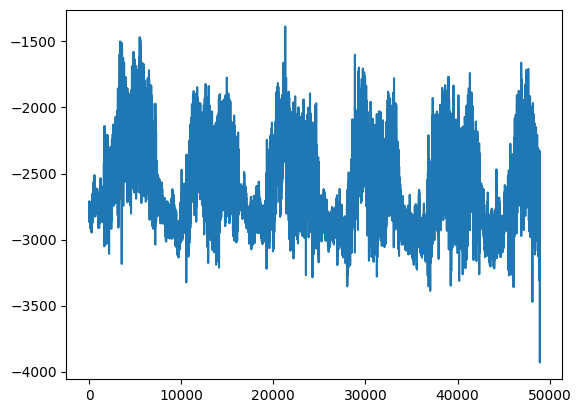

In [11]:
df['balance_check'].plot()

In [14]:
monthly_balance = (
    df
    .set_index('timestamp')
    ['balance_check']
    .resample('ME')
    .mean()
)

print(monthly_balance.head())
print(monthly_balance.tail())

timestamp
2020-01-31   -2760.069053
2020-02-29   -2728.581871
2020-03-31   -2650.437033
2020-04-30   -2494.315872
2020-05-31   -2281.015511
Freq: ME, Name: balance_check, dtype: float64
timestamp
2025-03-31   -2791.756322
2025-04-30   -2500.975096
2025-05-31   -2328.737583
2025-06-30   -2427.127987
2025-07-31   -2630.807104
Freq: ME, Name: balance_check, dtype: float64


In [15]:
print(df["balance_check"].describe())

print("\nYearly means:")
print(
    df.groupby(df["timestamp"].dt.year)["balance_check"]
      .mean()
)

count    48935.000000
mean     -2611.973004
std        281.818458
min      -3931.075478
25%      -2838.544419
50%      -2650.314537
75%      -2404.143324
max      -1386.408301
Name: balance_check, dtype: float64

Yearly means:
timestamp
2020   -2474.306229
2021   -2600.622691
2022   -2617.726369
2023   -2660.259549
2024   -2690.631280
2025   -2640.353146
Name: balance_check, dtype: float64


Year over year consistency like this supports the idea that the missing 2600 MW can be attributed to structural causes rather than missing generators - for which you'd expect wider variation. 


In [21]:
from load_data import load_pool_price_data
pool_df = load_pool_price_data()

generator_cols = [
    col for col in pool_df.columns
    if col not in [
        "Date_Begin_GMT",
        "Date_Begin_Local",
        "ACTUAL_POOL_PRICE",
        "ACTUAL_AIL",
        "HOUR_AHEAD_POOL_PRICE_FORECAST",
        "EXPORT_BC",
        "EXPORT_MT",
        "EXPORT_SK",
        "IMPORT_BC",
        "IMPORT_MT",
        "IMPORT_SK"
    ]
]

In [22]:
pool_df["gen_total"] = pool_df[generator_cols].sum(axis=1)

print(pool_df["gen_total"].describe())
print()
print(pool_df["ACTUAL_AIL"].describe())

count    48935.000000
mean      7078.100992
std        844.009110
min       4512.170862
25%       6483.843279
50%       7053.984782
75%       7630.691064
max      10241.685418
Name: gen_total, dtype: float64

count    48935.000000
mean      9846.494043
std        827.526124
min       7579.000000
25%       9257.000000
50%       9837.000000
75%      10457.000000
max      12384.000000
Name: ACTUAL_AIL, dtype: float64


/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_61207/932646564.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pool_df["gen_total"] = pool_df[generator_cols].sum(axis=1)


In [23]:
print(pool_df["gen_total"].mean())
print(pool_df["ACTUAL_AIL"].mean())

7078.100992241938
9846.494043118422


In [24]:
print(
    pool_df[[
        "gen_total",
        "ACTUAL_AIL"
    ]].corr()
)

            gen_total  ACTUAL_AIL
gen_total    1.000000    0.830679
ACTUAL_AIL   0.830679    1.000000
